<a href="https://colab.research.google.com/github/IraitzSantafosta/Emozioen-Analisia/blob/main/EmozioenAnalisia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Sare Sozial bateko datuen Emozioen Analisia

##Abstract

Lan honetan, Mastodon sare sozialeko mezuen emozioen analisia burutu dugu, klimaren aldaketari buruzko eztabaiden testuinguruan. Lehenik, ingelesezko datuak bildu ditugu eta aurreprozesamendu fase bat aplikatu dugu, non testuak garbitu eta anonimizatu ditugun. Ondoren, mezuak eskuz anotatu ditugu, eta emaitzak alderatzeko erreferentziazko etiketak sortu ditugu. Azterketa egiteko, lexikoi batean oinarritutako metodo bat eta transfer learning erabili ditugu, emozioen presentzia identifikatzeko. Azkenik, emaitzak ebaluatu ditugu F1-score eta bestelako neurriak erabiliz, gure anotazioak eta ereduaren aurreikuspenak konparatuz. Lortutako emaitzek sare sozialetan klimaren aldaketari buruzko diskurtso emozionala hobeto ulertzen lagundu dute.

##Sarrera

Sare sozialak informazio-trukerako eta eztabaidarako gune garrantzitsu bilakatu dira. Bertan, erabiltzaileek iritziak, sentimenduak eta emozioak partekatzen dituzte hainbat gairen inguruan. Horregatik, sare sozialetan emozioen analisia egitea interes handikoa da, gizartearen pentsamolde eta sentimendu orokorrak aztertzeko aukera ematen duelako.

Lan honetan, sare sozialetako mezuetan agertzen diren emozioak aztertzeko prozesua deskribatuko dugu. Zehazki, Mastodon sare sozialean klimaren aldaketari buruzko mezuen emozioen analisia egingo dugu, lexikoi batean oinarritutako hurbilpen bat erabiliz. Lanaren helburua zer emozio diren nagusi klimaren aldaketari buruzko eztabaidetan identifikatzea da eta aztertzea ea mezuen tonu orokorra positiboa, neutrala edo negatiboa den.

## Liburutegiak instalatu

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install Mastodon.py
!pip install bsky
!pip install trafilatura
!pip install atproto
!pip install Afinn
!pip install transformers datasets
!pip install afinn
!pip install spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 62.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import json
from mastodon import Mastodon
import spacy
import re
from afinn import Afinn
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from scipy.special import softmax
from sklearn.model_selection import train_test_split
from datasets import Dataset, ClassLabel
from sklearn.metrics import precision_score, accuracy_score, f1_score
import numpy as np
import shutil

## Datuak kargatu

Lehenik eta behin, Mastodon sare sozialetik klimaren aldaketarekin lotutako mezuak eskuratu ditugu. Horretarako, requests eta BeautifulSoup liburutegiak erabiliz, mastodon.social, mastodon.world, mastodon.xyz eta mastodon.eus zerbitzarietan kontsultak egin ditugu. Bilaketak climate change, global warming, environmental crisis eta ozone layer terminoen bidez burutu dira, eta 200 mezu bildu ditugu.

In [ ]:
# Bilaketa-gakoak definitu
query = ['climate change', 'global warming', 'environmental crisis', 'ozone layer']
# Mastodon zerbitzariak definitu
server=['mastodon.social', 'mastodon.world', 'mastodon.xyz', 'mastodon.eus']
# Datuak gordetzeko array hutsa sortu
data = []
# Zenbatzailea zeroan hasi
count=0

# Zerbitzari eta gako bakoitzeko
for s in server:
  for q in query:
      # Kontsulta URL-a sortu
      query_string = f'https://{s}/api/v1/timelines/tag/{q}'
      # Kontsulta egin
      response = requests.get(query_string)
      # JSON erantzuna prozesatu
      for res in response.json():
        # Ingelesezko mezuak bakarrik hartu
        if res["language"] == "en":
          # 200 mezura mugatu
          if count<200:
              # HTMLa garbitu BeautifulSoup-ekin
              c = BeautifulSoup(res["content"], features="html.parser")
              text = c.getText()
              # JSON objektua sortu
              json_obj = {"id": res["id"], "name": res["account"]["username"], "lang": res["language"], "text": text}
              # Datuen arrayan sartu
              data.append(json_obj)
              # Zenbatzailea gehitu
              count=count+1

# Pandas DataFrame bat sortu datuekin
df_en = pd.DataFrame.from_dict(data)
# DataFramea CSV fitxategi gisa gorde
df_en.to_csv('posts_en.csv', index=False)
# DataFramearen hasiera erakutsi
df_en.head()

,id,name,lang,text
0,114165976700887012,TheConversationClimate,en,Let juries judge disruptive protesters like Ju...
1,114165952446473808,05HR11,en,"first thing ,do not fight at all no winners th..."
2,114165918003302522,05HR11,en,“trump Cemetery scrubs info on famous white ve...
3,114165873161306466,bibliolater,en,🔴 🌊 🌡️ **OBSERVER: Copernicus Climate Cha...
4,114165854702858485,europesays,en,https://www.europesays.com/1914662/ Some US Sc...


Ikusi daitekeen moduan hauek dira lortutako tweet guztiak, 200eko maximoa ezarri dugu pentsatu dugulako ez zela beharrezkoa gehiago izatea. Begiratu dezakegu zenbat tweet ditugu:

In [ ]:
len(df_en)

200

Tweet hauek izanda, hauek garbitu behar izango ditugu eta erabilgarriak ez diren ikonoak edo testua kenduko dugu.

## Eskuzko anotazioak eskuratu


Anotazioa egiteko label-studio programa erabili dugu eta 200 testuei sentimendua aukeratu diegu 3 aukeren artean, sentimendu negatiboa, positiboa edo neutroa. Anotatuko datuak koadernoarekin batera entregatuta daude.

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/TDM/TDM LANA/posts_en_anotazioekin.csv')

In [ ]:
df.head()

,annotation_id,annotator,created_at,id,lang,lead_time,name,sentiment,text,updated_at
0,1,1,2025-03-12T16:59:18.302224Z,114150372842961942,en,2.747,suzannewhitby,neutral,Haunting work from Icelandic photographer Ragn...,2025-03-12T16:59:18.302224Z
1,3,1,2025-03-12T17:00:42.756903Z,114150352976170310,en,16.199,mudaste,positive,Excellent work by #TheGuardian on their visual...,2025-03-12T17:00:42.756903Z
2,2,1,2025-03-12T17:00:37.919145Z,114150333739931111,en,2.187,unibern,neutral,"Two years ago, global ocean temperatures rose ...",2025-03-12T17:00:37.919145Z
3,4,1,2025-03-12T17:00:58.466406Z,114150322191565670,en,14.445,ami,negative,I normally like #dystopian movies and the genr...,2025-03-12T17:00:58.466406Z
4,5,1,2025-03-12T17:01:14.521794Z,114150287858302022,en,14.338,DM_Ronin,positive,using ad blocker is right not only from privac...,2025-03-12T17:01:14.521794Z


Emaitzetan ondorioak ateratzerako orduan kontuan hartu behar dugu etiketak ez daudela probabilitate berdinarekin banatuta. Hauek dira portzentaiak:

In [ ]:
sentiment_counts = df['sentiment'].value_counts(normalize=True) * 100
print("Sentiment Label Percentages:")
for label, percentage in sentiment_counts.items():
    print(f"{label}: {percentage:.2f}%")

Sentiment Label Percentages:
negative: 49.00%
positive: 26.50%
neutral: 24.50%


## Preprozesaketa

Garbiketa + Anonimizazioa

Mezuak lortu eta anotatu ondoren, testuaren garbiketa eta anonimizazioa burutu ditugu, analisiaren zehaztasuna hobetzeko eta erabiltzaileen pribatutasuna babesteko. Prozesu honek hainbat urrats barne hartu ditu:

1. Testuaren garbiketa: clean_text funtzioan, URLak, erabiltzaileen aipamenak
(@user formatukoak), hashtag-ak eta puntuazio-markak kendu ditugu. Halaber, testua minuskulaz bihurtu eta stopword-ak ezabatu ditugu testuaren esanahia mantenduz baina zarata murriztuz.

1. Lematizazioa: preprocess_text funtzioan, Spacy-ren en_core_web_sm eredua erabiliz, hitzak beren forma lematizatura bihurtu ditugu, hau da, erro edo oinarrizko forma batera laburtu, testuaren analisia errazteko.

1. Anonimizazioa: anonymize_text_en funtzioan, pertsona-izenak, kokapenak eta erakunde-izenak detektatu ditugu Spacy-ren entitate-erauzketaren bidez. Ondoren, [PERSON/PLACE] etiketa erabiliz ordezkatu ditugu, erabiltzaileen pribatutasuna bermatzeko. Gainera, posta elektronikoak [MAIL] etiketa bidez anonimizatu ditugu.

1. CSV fitxategiaren eguneraketa: Azkenik, anonimizatutako testuak jatorrizko mezuen ordez gorde ditugu, eta azterketarako beharrezkoak ez ziren zutabeak ezabatu. Prozesu hau amaitzean, posts_en_processed.csv fitxategian gorde dugu informazio eguneratua.

In [ ]:
# Cargar modelo de Spacy para inglés
# Ingelesezko Spacy eredua kargatu
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    print("Ingelsezko eredua ez aurkitua. Instalatu honekin: !python -m spacy download en_core_web_sm")
    exit()

# Lista de stopwords en inglés
# Ingelesezko stop-hitz zerrenda
stopwords_en = set(spacy.lang.en.stop_words.STOP_WORDS)

# 1. Testuaren garbiketa:
def clean_text(text):
    text = re.sub(r'http\S+|www\S+', '', text)  # URLak kendu
    text = re.sub(r'@\w+', '[USER]', text)  # Aipamenak anonimzatu
    text = re.sub(r'#\w+', '', text)  # Hashtazak kendu
    text = re.sub(r'\S+@\S+', '[MAIL]', text)  # Email helbideak anonimizatu
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)  # Puntuazioa kendu
    text = text.lower().strip()  # Minuskulaz jarri eta soberako zuriuneak kendu
    return text

# 2. Lematizazioa:
def preprocess_text(text):
    doc = nlp(text)  # Testua Spacy-rekin prozesatu
    tokens = [token.lemma_ for token in doc if token.text not in stopwords_en and not token.is_punct and not token.is_space] # tokenak lortu
    return " ".join(tokens) # tokenak batu

# 3. Anonimizazioa:
def anonymize_text_en(text):
    # 1. NER erabiliz prozesatu
    doc = nlp(text) # Testua Spacy-rekin prozesatu
    anonymized_text = text # Testu anonimizatua

    for ent in doc.ents: # entitate bakoitzarentzat
        if ent.label_ in ['PERSON', 'GPE', 'LOC', 'ORG']: # pertsona, toki edo erakunde izenak badira
            if ent.text.endswith("'"): # apostrofarekin amaitzen bada
                anonymized_text = anonymized_text.replace(ent.text, ent.text[:-2] + " '[PERSON/PLACE]'") # [PERSON/PLACE] etiketarekin ordezkatu
            else: # bestela
                anonymized_text = anonymized_text.replace(ent.text, '[PERSON/PLACE]') # [PERSON/PLACE] etiketarekin ordezkatu

    # 2. Izen propio anitzeko bilaketa (heuristika hobetua)
    # Maiuskulaz idatzitako izen propioak bilatu
    words = anonymized_text.split() # hitzak banatu
    i = 0 # hasierako indizea
    while i < len(words): # hitz guztiak prozesatu arte
        if words[i].istitle() and words[i] not in ['[PERSON/PLACE]', '[USER]', '[MAIL]']: # maiuskulaz idatzita badago eta ez bada etiketa bat
            # Hurrengo hitza ere maiuskulaz idatzita dagoen egiaztatu
            j = i + 1 # hurrengo hitzaren indizea
            while j < len(words) and words[j].istitle() and words[j] not in ['[PERSON/PLACE]', '[USER]', '[MAIL]']: # hurrengo hitza ere maiuskulaz idatzita badago eta ez bada etiketa bat
                j += 1 # hurrengo hitzaren indizea eguneratu

            # Maiuskulaz idatzitako hitz sekuentzia bat aurkitzen bada, anonimotu
            if j > i + 1:  # Gutxienez bi hitz maiuskulaz idatzita badaude
                anonymized_text = anonymized_text.replace(" ".join(words[i:j]), '[PERSON/PLACE]') # [PERSON/PLACE] etiketarekin ordezkatu
                # Testua berriro banatu ordezkatu ondoren 'words' zerrenda eguneratzeko
                words = anonymized_text.split() # hitzak berriro banatu
                i = j  # Anonimizatutako izenaren ondoren jarraitu
            else: # bestela
                i += 1 # hurrengo hitzera pasa

        else: # bestela
            i += 1 # hurrengo hitzera pasa

    return anonymized_text # testu anonimizatua itzuli


# 4. CSV fitxategiaren eguneraketa:

# 1. Garbitu: clean_text funtzioa aplikatu
df['clean_text'] = df['text'].apply(clean_text)

# 2. Aurreprozesatu: preprocess_text funtzioa aplikatu
df['processed_text'] = df['clean_text'].apply(preprocess_text)

# 3. Anonimizatu: anonymize_text_en funtzioa aplikatu
df['anonymized_text'] = df['processed_text'].apply(anonymize_text_en)

# Prozesatutako CSV fitxategia gorde
df.to_csv('posts_en_processed.csv', index=False)

df.head()

,annotation_id,annotator,created_at,id,lang,lead_time,name,sentiment,text,updated_at,clean_text,processed_text,anonymized_text
0,1,1,2025-03-12T16:59:18.302224Z,114150372842961942,en,2.747,suzannewhitby,neutral,Haunting work from Icelandic photographer Ragn...,2025-03-12T16:59:18.302224Z,haunting work from icelandic photographer ragn...,haunt work icelandic photographer ragnar axels...,haunt work icelandic photographer ragnar axels...
1,3,1,2025-03-12T17:00:42.756903Z,114150352976170310,en,16.199,mudaste,positive,Excellent work by #TheGuardian on their visual...,2025-03-12T17:00:42.756903Z,excellent work by on their visual explainer a...,excellent work visual explainer deepsea mining...,excellent work visual explainer deepsea mining...
2,2,1,2025-03-12T17:00:37.919145Z,114150333739931111,en,2.187,unibern,neutral,"Two years ago, global ocean temperatures rose ...",2025-03-12T17:00:37.919145Z,two years ago global ocean temperatures rose s...,year ago global ocean temperature rise sharply...,year ago global ocean temperature rise sharply...
3,4,1,2025-03-12T17:00:58.466406Z,114150322191565670,en,14.445,ami,negative,I normally like #dystopian movies and the genr...,2025-03-12T17:00:58.466406Z,i normally like movies and the genre in gener...,normally like movie genre general not help thi...,normally like movie genre general not help thi...
4,5,1,2025-03-12T17:01:14.521794Z,114150287858302022,en,14.338,DM_Ronin,positive,using ad blocker is right not only from privac...,2025-03-12T17:01:14.521794Z,using ad blocker is right not only from privac...,ad blocker right privacy perspective helpful g...,ad blocker right privacy perspective helpful g...


Hemen ikusi daitezke eta "csv" fitxategian nabarmendu daitezke egindako pausu bakoitza garbiketa osoa eta anonimizazioa egiteko, clean_text, processed_text eta anonymized_text-ean banatuta.

## Datuak etreamendu eta test multzota banatu

In [ ]:
# ---CHANGE START---
# 'sentiment' zutabeak 'negative', 'neutral', 'positive' etiketak dituela suposatuz
label_mapping = {'negative': 0, 'neutral': 1, 'positive': 2}
df['labels'] = df['sentiment'].map(label_mapping) # 'sentiment' zutabea 'labels' izendatu
# ---CHANGE END---

# datuak banatu
train_df, temp_df = train_test_split(df, test_size=0.4, random_state=42)  # %60 entrenatzeko
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42) # 20% dev, 20% test

##Lexicon(Afinn)

Lan honetako analisiaren hurrengo fasea emozioen detekzioa da, eta horretarako Afinn lexikoa erabiliko dugu, emozioak identifikatzeko eta sailkatzeko. Afinn, emozioen analisia egiteko erabilitako tresna bat da, eta bertan, mezuen sentimenduak (positiboak, negatiboak edo neutroak) identifikatzen dira puntuazio baten bidez.

Afinn-en Oinarritutako Analisiaren Funtzionamendua
Lehenik, Afinn moduluaren bidez emozioen analisia egiteko aukera ematen duen objektu bat sortzen dugu. Afinn lexikoa oinarri hartuta, mezuen emozioen puntuazioa kalkulatu ahal izango dugu.

Emozioen analisiaren funtzioak testu bat hartzen du eta Afinn-en score funtzioa erabiltzen du, testuaren puntuazio emozionala lortzeko. Puntuazioa positiboa bada, "positibo" itzultzen du; negatiboa bada, "negatibo" eta 0 bada, "neutro". Hori dela eta, testuaren emozioaren sailkapen orokorra lortzen dugu.

Ondoren, analisi hori datu-multzo batean aplikatzen dugu, eta mezu bakoitzeko emozioen sailkapena kalkulatzen dugu. Horrela, mezuen emozioak identifikatzen dira, eta emaitzak datu-egitura batean gordetzen dira, hurrengo analisi faseetarako erabilgarri izateko.

Azkenik, emaitzak CSV fitxategi batean gordetzen dira, eta horrela, analisiaren emaitzak modu egituratuan eta erabilerrazean eskuragarri daude.

In [ ]:
# Afinn hasieratu
afinn = Afinn()

# 1. Emozioak aztertzeko funtzioa (AFINN)
def analyze_emotions(text):
    # Emozio puntuazioa lortu
    sentiment_score = afinn.score(text)

    # Kategoriak definitzeko
    if sentiment_score > 0:
        return {"emotion": "positive", "score": sentiment_score}
    elif sentiment_score < 0:
        return {"emotion": "negative", "score": sentiment_score}
    else:
        return {"emotion": "neutral", "score": sentiment_score}

# 2. Analisi funtzioa (dataset-ean aplikatzeko)
# test_df erabiltzeko aldatuta
def analyze_dataset(df):
    df['anonymized_text'] = df['anonymized_text'].astype(str)

    # Emozioen analisia aplikatu
    df['emotions'] = df['anonymized_text'].apply(lambda x: analyze_emotions(x))

    return df

# 3. Emaitzak CSV fitxategian gorde
def save_results(df, output_path):
    df.to_csv(output_path, index=False)

# 4. Analisi funtzioa (datu basean exekutatzeko)
# test_df erabiltzeko aldatuta
def run_analysis(df, output_file):
    df_result = analyze_dataset(df)
    save_results(df_result, output_file)

# Analisi exekutatu (test_df erabiliz)
output_file = "tweets_emotion_analysis_afinn.csv"  # Emaitzen fitxategia

run_analysis(test_df, output_file) # test_df erabiliz

Emozioen analisia egiteko, AFINN lexikoiaren oinarritutako metodoa erabili dugu, mezuetan agertzen diren emozioak identifikatzeko. Analisi hau aplikatuz, mezuak hiru kategorietan sailkatu ditugu: positiboak, negatiboak eta neutroak. Ondoren, emaitzak bildu eta irudikatzean, honako hauek izan dira lortutako emaitzak:


<ipython-input-15-795f67bfdca6>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sentiment', y='Count', data=sentiment_df, palette="coolwarm")


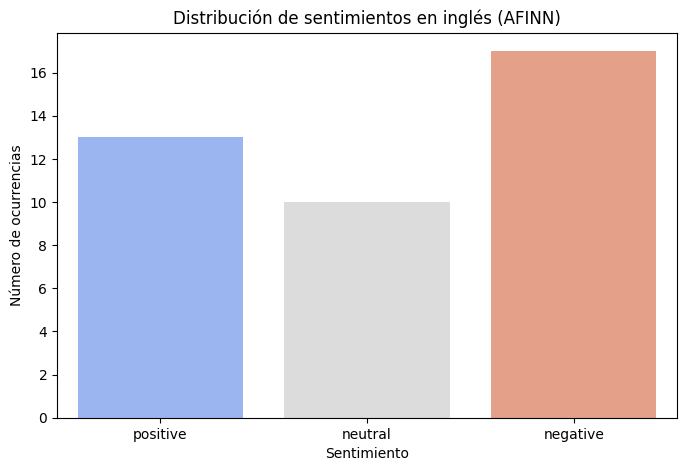

In [ ]:
# 1. Ingelesezko datasetarako emozioak irudikatzeko funtzioa AFINN erabiliz
def plot_emotions_english(df):
    # Emozio positiboak, negatiboak eta neutroak zenbatu
    sentiment_counts = {'positive': 0, 'neutral': 0, 'negative': 0}
    for emotions in df['emotions']:
        # Hiztegiaren kate-irudikapena benetako hiztegi bihurtu
        emotions_dict = eval(emotions)
        sentiment_counts[emotions_dict['emotion']] += 1

    # Zenbaketa DataFrame bihurtu
    sentiment_df = pd.DataFrame(list(sentiment_counts.items()), columns=['Sentiment', 'Count'])

    # Grafikoa sortu
    plt.figure(figsize=(8,5))
    sns.barplot(x='Sentiment', y='Count', data=sentiment_df, palette="coolwarm")
    plt.title('Distribución de sentimientos en inglés (AFINN)')
    plt.xlabel('Sentimiento')
    plt.ylabel('Número de ocurrencias')
    plt.show()

# 2. Ingelesezko datasetarako analisia aplikatu eta grafikoa sortzeko funtzioa
def run_analysis_english(input_file):
    # CSV fitxategiko datuak pandas DataFrame batean kargatu
    df = pd.read_csv(input_file)
    plot_emotions_english(df)

# Ingelesezko datasetarako analisia eta grafikoa exekutatu
input_file_english = "/content/tweets_emotion_analysis_afinn.csv"
run_analysis_english(input_file_english)

In [ ]:
df_afinn = pd.read_csv("/content/tweets_emotion_analysis_afinn.csv")
predi_afinn = df_afinn["emotions"].apply(lambda x: eval(x)["emotion"])
kont = predi_afinn.value_counts()
print(kont)
df_afinn.head()

,annotation_id,annotator,created_at,id,lang,lead_time,name,sentiment,text,updated_at,clean_text,processed_text,anonymized_text,labels,emotions
0,10,1,2025-03-12T17:04:23.467493Z,114150173510544968,en,34.925,vir_borealis,positive,How do we ensure cooperation with future gener...,2025-03-12T17:04:23.467493Z,how do we ensure cooperation with future gener...,ensure cooperation future generation researche...,ensure cooperation future generation researche...,2,"{'emotion': 'positive', 'score': 4.0}"
1,96,1,2025-03-12T17:31:31.389110Z,114149845204503453,en,4.486,Snoro,negative,"More than nine months after the deadline, the ...",2025-03-12T17:31:31.389110Z,more than nine months after the deadline the e...,month deadline eu commission today give belgiu...,month deadline eu commission today give belgiu...,0,"{'emotion': 'negative', 'score': -4.0}"
2,149,1,2025-03-12T17:40:54.012264Z,112790634544141781,en,6.146,formuchdeliberation,negative,Wildfires threaten the recovery of the ozone l...,2025-03-12T17:40:54.013287Z,wildfires threaten the recovery of the ozone l...,wildfire threaten recovery ozone layer earthco...,wildfire threaten recovery ozone layer earthco...,0,"{'emotion': 'positive', 'score': 4.0}"
3,19,1,2025-03-12T17:08:37.647108Z,114149894306902593,en,23.794,edwiebe,negative,Everyone. Pay attention. The COP meetings are ...,2025-03-12T17:08:37.647108Z,everyone pay attention the cop meetings are no...,pay attention cop meeting problem new highway ...,pay attention cop meeting problem new highway ...,0,"{'emotion': 'neutral', 'score': 0.0}"
4,83,1,2025-03-12T17:29:15.646875Z,114150229643019917,en,5.223,TexasObserver,neutral,From our friends at @grist: At any given momen...,2025-03-12T17:29:15.646875Z,from our friends at user at any given moment m...,friend user give moment 10000 satellite whiz p...,friend user give moment 10000 satellite whiz p...,1,"{'emotion': 'positive', 'score': 1.0}"



13 mezu positibo: Emaitza honek adierazten du klimaren aldaketari buruzko mezuetan ikuspegi positibo bat duten erabiltzaileek nahiko parte hartzen dutela.

17 mezu negatibo: Mezu negatiboek, orokorrean, gizartean eragin handia duten kezka eta mehatxuak erakusten dituzte, eta adierazten dute zer nolako alarma eta beldur dagoen klimaren aldaketaren inguruan.

10 mezu neutro: Mezu neutroek adierazten dute informazio edo deskribapen objektiboagoa dagoela, eta ez dagoela emozio handirik bertan. Mezu horiek, gehienetan, klimataren aldaketaren egoera eta datuak modu informatiboan azaltzen dituzte, iritzi emozionalik gabe.

Exekutatzen den bakoitzean desberdintasun txiki bat izan dezakete balioak

##Transfer Learning

Transfer Learning edo aplikazio-aplikazio ikaskuntza teknikak ezagutza batetik bestera transferitzea ahalbidetzen du, hau da, modelo preentrenatu bat erabiliz, bertan lortutako ezagutza beste taska batzuetan aplikatzea. Teknika hau bereziki erabilgarria da datu gutxi daudenean, modeloa hasieratik entrenatzea baino. RoBERTa eta BERT bezalako transformadore-moduloek, aurretik hainbat testuingurutan entrenatuta, sintaxiaren eta testuinguruaren ulermen orokorra dute, eta hori ahalbidetzen du Transfer Learning-ek.

Gure kasuan, "cardiffnlp/twitter-roberta-base-sentiment" modeloak, Twitter-en oinarritutako sentimenduetan prestatu den modelo bat da, eta Transfer Learning aplikatu dugu, saretako mezuetan emozioen analisia egiteko. Horrela, modeloa ez da entrenatu tweet bakar batzuetan, baizik eta aurretik sare sozialen testuinguru zabalago batean. Gainera, gure datuen portzentai batekin entrenatuko dugu eredua gure datuetara hobeto egokitzeko.

In [ ]:
# Modeloak eta tokenizatzaileak kargatu
models = {
    "en": "cardiffnlp/twitter-roberta-base-sentiment"
}
tokenizers = {lang: AutoTokenizer.from_pretrained(model) for lang, model in models.items()}
models = {lang: AutoModelForSequenceClassification.from_pretrained(model) for lang, model in models.items()}

# Emozioak aurreikusteko funtzioa
def predict_emotion(text, lang="en"):
    tokenizer = tokenizers[lang]
    model = models[lang]

    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs)

    scores = outputs.logits.numpy()[0]
    scores = softmax(scores)  # Probabilitateetara bihurtu

    if lang == "en":  # Ingelesezko modeloak 3 klase ditu
        emotions = ["negative", "neutral", "positive"]

    return {emotions[i]: scores[i] for i in range(len(scores))}


# Datuak tokenizatzeko funtzioa
def tokenize_function(examples):
    # Ziurtatu examples["anonymized_text"] string zerrenda bat dela
    # string ez diren balioak badaude (adibidez, NaN)
    texts = [str(text) for text in examples["anonymized_text"]]
    return tokenizers["en"](texts, padding="max_length", truncation=True, max_length=128) # max_length balio koherente batera ezarri

# ClassLabel ezaugarria definitu 'sentiment' zutaberako
class_label = ClassLabel(num_classes=3, names=['negative', 'neutral', 'positive'])

# Dataset-ak sortu doikuntza finetarako
train_dataset = Dataset.from_pandas(train_df[["anonymized_text", "labels"]]).map(tokenize_function, batched=True) # 'labels' erabili hemen
train_dataset = train_dataset.cast_column("labels", class_label) # 'labels' ClassLabel-era bihurtu

val_dataset = Dataset.from_pandas(val_df[["anonymized_text", "labels"]]).map(tokenize_function, batched=True) # 'labels' erabili hemen
val_dataset = val_dataset.cast_column("labels", class_label) # 'labels' ClassLabel-era bihurtu

# Entrenatzeko argumentuak definitu
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,  # Beharrezkoa den moduan egokitu
    evaluation_strategy="epoch", # Zaharkituta, etorkizuneko bertsioetan kenduko da
    eval_strategy="epoch", # Hau erabili evaluation_strategy-ren ordez etorkizuneko bertsioetan
    learning_rate=2e-5,
    weight_decay=0.01,
)


# Entrenatzailea sortu eta modeloa entrenatu
trainer = Trainer(
    model=models["en"],
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

trainer.train()

# make a copy of test_df
df_roberta = test_df.copy()

# Emozioen analisia aplikatu doitutako modeloarekin
df_roberta["emotions_finetuned"] = df_roberta["anonymized_text"].astype(str).apply(lambda x: predict_emotion(x, lang="en"))

# Emozioen hiztegia zutabe bereizietan bihurtu
df_roberta = df_roberta.join(pd.json_normalize(df_roberta["emotions_finetuned"]), rsuffix="_finetuned")

# Emozioen banaketa irudikatu
def plot_emotions(df, title):
    emotion_counts = df[["negative", "neutral", "positive"]].mean()
    emotion_counts.plot(kind="bar", color=["red", "gray", "green"], alpha=0.7)

    plt.title(title)
    plt.ylabel("Average Probability")
    plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 1, 1)
plot_emotions(test_df, "Distribución de sentimientos en inglés (Pretrained Model)")

plt.tight_layout()
plt.show()

# Emaitzak gorde
df_roberta.to_csv("tweets_emotion_analysis_rob_finetuned.csv", index=False)

# Gorde Drive-n
nombre_archivo = 'tweets_emotion_analysis_rob_finetuned.csv'
ruta_destino = '/content/drive/MyDrive/Colab Notebooks/TDM/TDM LANA/' + nombre_archivo
shutil.copyfile('/content/' + nombre_archivo, ruta_destino)

Map:   0%|          | 0/120 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/120 [00:00<?, ? examples/s]

Map:   0%|          | 0/40 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/40 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss


Honek adierazten du, tweeten %48k emozio neutroa izan dutela, eta gainerakoek sentimendu negativo eta positiboaren artean banatuta daudela, baina kasu gehienetan, neutralitatea nagusi izan dela.

Negatibo (0.32): Tweeten %32ak izan dira negatiboak. Balio hau ez da altua, baina adierazten du mezu batzuetan sentimendu negatiboak daudela.

Positibo (0.20): %20 tweet positiboak izan dira, baina balio baxuagoa lortu du, emozio positiboak adierazteko adina argitasunik ez dutela sugiere.

Neutrala (0.48): %48 tweet neutroak izan dira, hau da, mezuen erdia inguruan ez du sentimendu nabarmenik, eta horrek testu moderatuak edo informazio neutrala islatzen du.

Lortutako emaitzek erakusten dute sare sozialetan, Twitter-en, mezu askok ez dutela sentimendu intentsu edo argirik, eta neutralitatea nagusi den arren, emozio negatibo eta positiboek ere presentzia dute, nahiz eta balio txikiagoak izan. Hau da, mezu gehienak ez dira garrantzi handiko emozioek kargatuta, eta testuak edo informazioa adierazteko erabiltzen diren gehiago.

Transfer Learning erabiliz, RoBERTa modeloak oso ondo funtzionatu du tweeten emozioen identifikazioan, baina oreka bat dago emozio guztien artean, eta azterketak adierazi duenez, neutralitatea da nagusi.

Emaitzen konparaketa

##Emaitzen konparaketa

In [ ]:
# AFINN eta RoBERTa-ren aurreikuspenak eta benetako etiketak kargatu
df_afinn = pd.read_csv("/content/tweets_emotion_analysis_afinn.csv")
df_roberta = pd.read_csv("/content/tweets_emotion_analysis_rob_finetuned.csv")

predicciones_afinn = df_afinn["emotions"].apply(lambda x: eval(x)["emotion"])
predicciones_roberta = df_roberta["emotions"].apply(lambda x: eval(x)["emotion"])

# AFINN-rako metriak kalkulatu
precision_afinn = precision_score(test_df["sentiment"], predicciones_afinn, average='weighted')
accuracy_afinn = accuracy_score(test_df["sentiment"], predicciones_afinn)
f1_afinn = f1_score(test_df["sentiment"], predicciones_afinn, average='weighted')

# RoBERTa-rako metriak kalkulatu
precision_roberta = precision_score(test_df["sentiment"], predicciones_roberta, average='weighted')
accuracy_roberta = accuracy_score(test_df["sentiment"], predicciones_roberta)
f1_roberta = f1_score(test_df["sentiment"], predicciones_roberta, average='weighted')

# Metriak inprimatu
print("AFINN - Precision:", precision_afinn)
print("AFINN - Accuracy:", accuracy_afinn)
print("AFINN - F1 score:", f1_afinn)
print("RoBERTa - Precision:", precision_roberta)
print("RoBERTa - Accuracy:", accuracy_roberta)
print("RoBERTa - F1 score:", f1_roberta)

# AFINN-rako etiketa bakoitzaren portzentajea kalkulatu
unique_labels = np.unique(test_df["sentiment"])  # Etiketa bakarrak lortu
porcentajes_afinn = {}
for label in unique_labels:
  porcentajes_afinn[label] = (predicciones_afinn == label).sum() / len(predicciones_afinn) * 100

# RoBERTa-rako etiketa bakoitzaren portzentajea kalkulatu
porcentajes_roberta = {}
for label in unique_labels:
  porcentajes_roberta[label] = (predicciones_roberta == label).sum() / len(predicciones_roberta) * 100

# Portzentajeak inprimatu
print("\nEtiketa portzentaia AFINN:")
for label, porcentaje in porcentajes_afinn.items():
  print(f"{label}: {porcentaje:.2f}%")

print("\nEtiketa portzentaia RoBERTa:")
for label, porcentaje in porcentajes_roberta.items():
  print(f"{label}: {porcentaje:.2f}%")

# Benetako portzentajeak
print("\nBenetako etiketa portzentaia:")
for label in unique_labels:
  porcentaje_real = (df["sentiment"] == label).sum() / len(df) * 100
  print(f"{label}: {porcentaje_real:.2f}%")

##Ondorioak


Bi ikuspegi aplikatu dira: AFINN lexikoan oinarritutako metodo bat eta Transfer Learning teknika erabiliz RoBERTa eredua.

Emaitzek erakusten dute RoBERTak AFINN baino errendimendu hobea lortzen duela, zehaztasun, doitasun eta F1 puntuazio pixka bat handiagoak eskuratuz. Hau RoBERTaren arkitekturari zor zaio, izan ere, transformers oinarritutako eredu bat denez eta datu-multzo handietan aurrez entrenatua dagoenez, hizkuntzaren eta mezuen testuinguruaren konplexutasuna hobeto jasotzeko gaitasuna du. Aldiz, AFINN lexiko batean oinarritutako metodoa denez, adierazpen konplexuak eta sarkasmoa interpretatzeko mugak ditu, eta horrek bere errendimenduan eragina du.

Hala ere, bi ereduek ezin izan dute emozioen sailkapenean doitasun perfektua lortu, bereziki mezu negatiboak identifikatzerakoan. Horren arrazoia hainbat faktore izan daitezke:

* Hizkuntzaren konplexutasuna: Sare sozialetako mezuetan hizkuntza kolokiala, laburdurak, ironia eta sarkasmoa erabiltzen dira askotan, eta horrek analisia zailtzen du.

* Emozioen subjektibotasuna: Emozioak interpretatzea subjektiboa izan daiteke, baita giza anotatzaileentzat ere, eta horrek errore-maila bat dakar analisian.

* Klaseen desoreka: Emozio mota bakoitzeko mezu kopuru desberdina egon daiteke, eta horrek ereduak entrenatzeko eragina izan dezake.

* Datu-multzoaren tamaina: Datu-multzo handiago eta anitzago batek ereduen orokortzeko gaitasuna hobetu lezake.

Lan honek erakusten du Transfer Learning teknikak, RoBERTa bezalako ereduak erabiliz, sare sozialetako emozioen analisia egiteko aukera bikaina eskaintzen duela, lexikoetan oinarritutako metodoak gaindituz errendimenduan.
Azpimarratzekoak dira ereduak ebaluatzeko eskuzko anotazioaren garrantzia.
Agian testuaren preprozesmendu kompexuago batekin emaitza hobeak lortu ditezke.

